In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers,models
import matplotlib.pyplot as plt
# a  # Remove or comment out this line since 'a' is not defined

In [2]:
dir(keras)

['DTypePolicy',
 'FloatDTypePolicy',
 'Function',
 'Initializer',
 'Input',
 'InputSpec',
 'KerasTensor',
 'Layer',
 'Loss',
 'Metric',
 'Model',
 'Operation',
 'Optimizer',
 'Quantizer',
 'Regularizer',
 'RematScope',
 'Sequential',
 'StatelessScope',
 'SymbolicScope',
 'Variable',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 'activations',
 'applications',
 'backend',
 'callbacks',
 'config',
 'constraints',
 'datasets',
 'device',
 'distillation',
 'distribution',
 'dtype_policies',
 'export',
 'initializers',
 'layers',
 'legacy',
 'losses',
 'metrics',
 'mixed_precision',
 'models',
 'name_scope',
 'ops',
 'optimizers',
 'preprocessing',
 'quantizers',
 'random',
 'regularizers',
 'remat',
 'tree',
 'utils',
 'version',
 'visualization',
 'wrappers']

In [3]:
dir(keras.datasets)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'boston_housing',
 'california_housing',
 'cifar10',
 'cifar100',
 'fashion_mnist',
 'imdb',
 'mnist',
 'reuters']

In [4]:
from keras.datasets import fashion_mnist

In [5]:
fashion_mnist.load_data

<function keras.src.datasets.fashion_mnist.load_data()>

In [6]:
datasets.fashion_mnist.load_data()

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [7]:
dir(fashion_mnist)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'load_data']

In [8]:
type(fashion_mnist)

module

In [9]:
(X_train,y_train),(X_test,y_test)=datasets.fashion_mnist.load_data()
X_train.shape

(60000, 28, 28)

In [10]:
X_train[0].shape

(28, 28)

In [11]:
y_train[0]

9

In [12]:
class_names = ['top', 'trouser', 'pullover', 'dress', 'coat',
               'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
# y_train[:5]
# X_train[0] # 9 ==== Shoe
# X_train[1] # 0 === top
# X_train[2] # 0 === top
# X_train[3] # 3 === dress
# X_train[4] # 0 === top
# Total 60k images
# the divides into 10 classes

In [13]:
y_train[0]

9

In [14]:
class_names[y_train[0]]

'ankle boot'

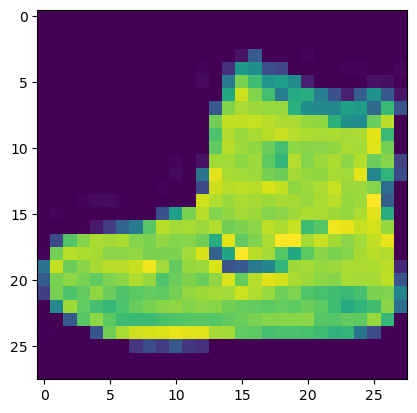

In [15]:
plt.imshow(X_train[0])

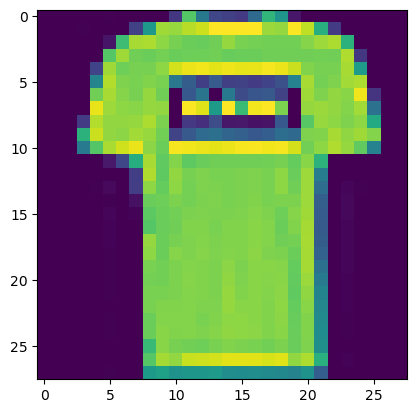

In [16]:
plt.imshow(X_train[1])

Text(0.5, 0, '0')

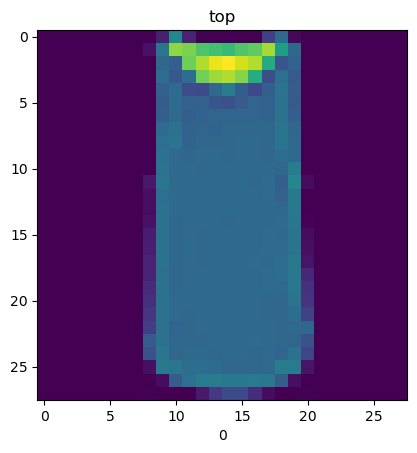

In [17]:
plt.imshow(X_train[2])
plt.title(class_names[y_train[2]])
plt.xlabel(y_train[2])

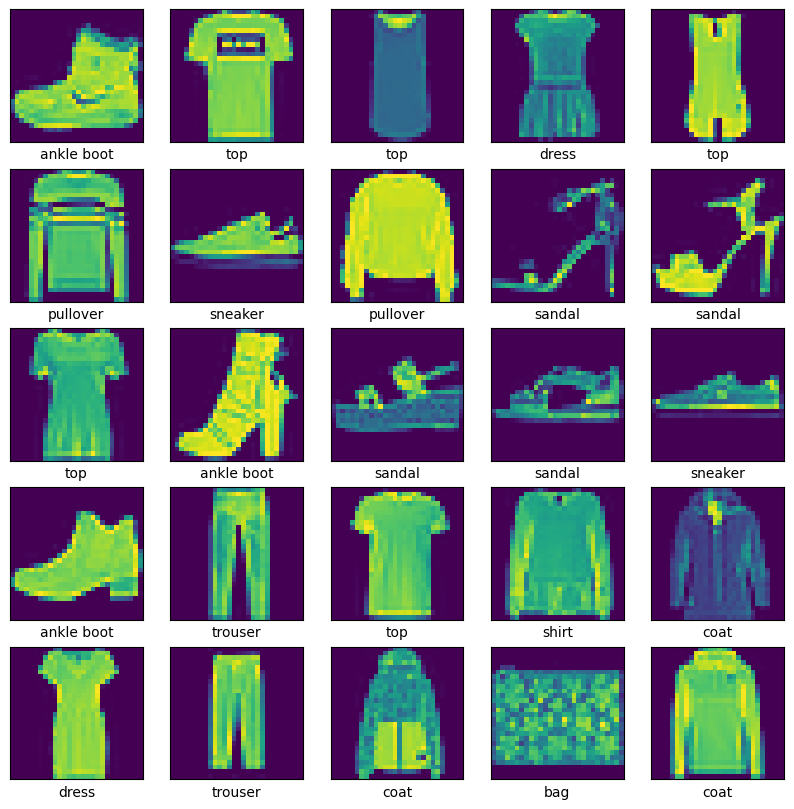

In [18]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.xlabel(class_names[y_train[i]])
plt.show()

In [19]:
X_train = X_train/255
X_test = X_test/255

In [20]:
X_train

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [21]:
X_train.shape

(60000, 28, 28)

In [22]:
from tensorflow.keras import datasets, layers,models
model=models.Sequential()

#############################################################################################
model.add(layers.Conv2D(32, # filters
                        (3,3), # filter size/kernal size
                        activation='relu',
                        input_shape=(28,28,1)
                        ))  # Stride / padding : default

model.add(layers.MaxPool2D((2,2)))  # shape of the pool

###############################################################################################
model.add(layers.Conv2D(64, # filters
                        (3,3), # filter size/kernal size
                        activation='relu'))  # stride /padding: deafault

model.add(layers.MaxPool2D((2,2)))

###############################################################################################

model.add(layers.Conv2D(64, # filters
                        (3,3), # filter size/kernal size
                        activation='relu'))

C:\Users\Dell\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 64)            │          36,928 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 55,744 (217.75 KB)

 Trainable params: 55,744 (217.75 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.add(layers.Flatten()) # After convolution ==== Fully connect layer
# no need of input shape here
model.add(layers.Dense(64,activation='relu'))  # Hidden layer 64 neurons, relu activation function
#model.add(layers.Dense(10)) # 10 classes so 10 neurons
model.add(layers.Dense(10,activation='softmax')) # softmax activation function

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 576)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(optimizer="adam",
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=["accuracy"])

In [27]:
history = model.fit(X_train,y_train,
          epochs=10,
          validation_split=0.2)

Epoch 1/10


C:\Users\Dell\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\nn.py:1402: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8100 - loss: 0.5221 - val_accuracy: 0.8658 - val_loss: 0.3690
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8789 - loss: 0.3339 - val_accuracy: 0.8821 - val_loss: 0.3289
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8950 - loss: 0.2865 - val_accuracy: 0.8980 - val_loss: 0.2842
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9078 - loss: 0.2533 - val_accuracy: 0.8931 - val_loss: 0.2912
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9150 - loss: 0.2297 - val_accuracy: 0.9020 - val_loss: 0.2677
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9225 - loss: 0.2085 - val_accuracy: 0.9071 - val_loss: 0.2691
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9300 - loss: 0.1902 - val_accuracy: 0.9106 - val_loss: 0.2480
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9362 - loss: 0.1718 - val_a

In [28]:
history.history

{'accuracy': [0.8100208044052124,
  0.8788958191871643,
  0.8949791789054871,
  0.9077708125114441,
  0.9150208234786987,
  0.9224791526794434,
  0.9300416707992554,
  0.9361666440963745,
  0.9409999847412109,
  0.9465416669845581],
 'loss': [0.5221369862556458,
  0.3338915705680847,
  0.28649765253067017,
  0.25330761075019836,
  0.22970598936080933,
  0.20853480696678162,
  0.19021591544151306,
  0.17177672684192657,
  0.15661507844924927,
  0.14283257722854614],
 'val_accuracy': [0.8657500147819519,
  0.8820833563804626,
  0.8980000019073486,
  0.8930833339691162,
  0.9020000100135803,
  0.9070833325386047,
  0.9105833172798157,
  0.9109166860580444,
  0.902916669845581,
  0.9074166417121887],
 'val_loss': [0.36899951100349426,
  0.32888978719711304,
  0.28420722484588623,
  0.291236013174057,
  0.267709881067276,
  0.26912838220596313,
  0.24795062839984894,
  0.2550957500934601,
  0.27878469228744507,
  0.2785899341106415]}

Text(0, 0.5, 'Accuracy')

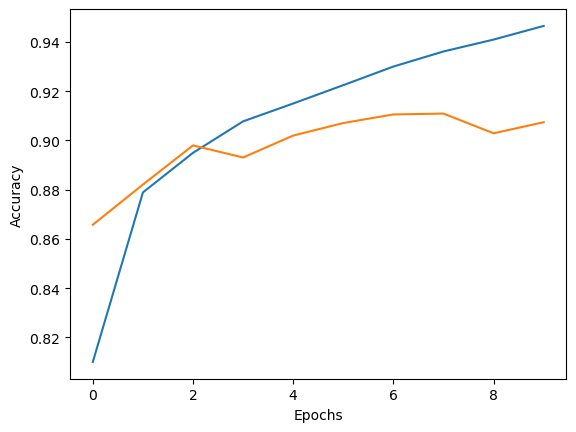

In [29]:
plt.plot(history.history["accuracy"],label="accuracy")
plt.plot(history.history["val_accuracy"],label="val_accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")


(0.5, 1.0)

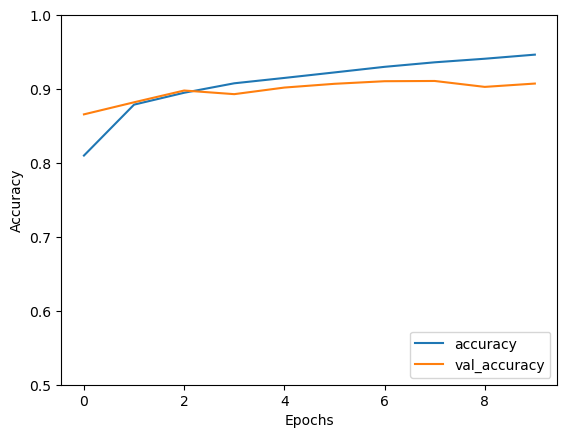

In [30]:
plt.plot(history.history["accuracy"],label="accuracy")
plt.plot(history.history["val_accuracy"],label="val_accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")  # It will move legends marks to lower right side of output graph.
plt.ylim([0.5,1])              # It will make the y_axis marks in between 0.5 to 1.0

In [31]:
model.weights

[<Variable path=sequential/conv2d/kernel, shape=(3, 3, 1, 32), dtype=float32, value=[[[[ 1.61014438e-01  7.56327361e-02  2.28533477e-01  1.92892894e-01
     -7.91561186e-01 -8.79614335e-03 -1.22425251e-01 -1.13825254e-01
     -2.06008852e-01  7.25840703e-02  1.57317072e-01  4.82241437e-02
     -1.36052802e-01  6.37444183e-02  2.25022465e-01 -2.42959838e-02
     -9.78962630e-02  1.04438700e-01 -5.45469105e-01  3.46094295e-02
     -1.07405186e-02 -2.18229368e-01  2.96425641e-01 -2.29583219e-01
      3.56595553e-02  7.14390054e-02 -1.04795163e-02 -3.55724365e-01
     -4.20414805e-01 -1.12994015e+00 -2.10197434e-01  5.68023250e-02]]
 
   [[ 2.70752888e-02 -7.24088550e-01 -8.19955245e-02  1.75495178e-01
     -9.87012565e-01  2.07786456e-01  1.70374170e-01 -6.87406883e-02
     -3.06082726e-01  1.74305867e-02 -4.36993204e-02 -1.83807999e-01
     -1.55312151e-01  9.32557434e-02  5.28810918e-03 -1.09191966e+00
     -1.04486234e-01  1.19890496e-01 -1.20320606e+00  2.85568684e-01
     -9.28620696

In [32]:
y_test.flatten()

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

### Prediction : 

In [33]:
X_test[0].shape

(28, 28)

In [35]:
import numpy as np
import pandas as pd

y_pred = model.predict(X_test[0])
y_pred

NameError: name 'X_test1' is not defined

In [36]:
# we are getting the input shape error, cause we need 3D image to predict but we have 2D
# So,


X_test1 = np.expand_dims(X_test[0], axis=0)
X_test1

array([[[0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.

In [37]:
y_pred = model.predict(X_test1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


array([[1.5493686e-08, 1.4906912e-10, 2.4589988e-11, 5.0786775e-10,
        2.1475288e-10, 2.1089909e-06, 9.4427981e-13, 4.8958500e-06,
        2.0799213e-09, 9.9999297e-01]], dtype=float32)

In [38]:
np.max(y_pred), np.argmax(y_pred)

(0.99999297, 9)

In [39]:
X_test1[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [40]:
X_test.shape

(10000, 28, 28)

In [41]:
y_pred = model.predict(X_test)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[1.5493658e-08, 1.4906912e-10, 2.4589939e-11, ..., 4.8958409e-06,
        2.0799173e-09, 9.9999297e-01],
       [6.5356211e-08, 7.8417467e-11, 9.9999976e-01, ..., 5.3917323e-17,
        7.7425053e-09, 9.6239891e-12],
       [7.5263370e-14, 1.0000000e+00, 1.7804927e-13, ..., 8.3477932e-24,
        4.7467733e-14, 3.8384324e-19],
       ...,
       [3.6182719e-13, 4.6184863e-16, 4.7389328e-13, ..., 1.9867953e-16,
        1.0000000e+00, 7.4160768e-16],
       [7.9384485e-12, 1.0000000e+00, 6.5144572e-14, ..., 1.4168239e-18,
        2.8157693e-13, 8.3384062e-16],
       [1.0735839e-04, 2.5980782e-07, 9.1934398e-06, ..., 3.9982330e-03,
        7.1736955e-05, 2.7435875e-04]], dtype=float32)

In [ ]:
y_pred = model.predict(X_test) 
max_prob = [np.max(i) for i in y_pred]
max_prob_index = [np.argmax(j) for j in y_pred]


In [44]:
import numpy as np
import pandas as pd

y_pred = model.predict(X_test)      # 10k images === 10k predictions
max_prob=[np.max(i)  for i in y_pred]    # Each prediction max prob saving in a list
max_prob_index=[np.argmax(i) for i in y_pred]     # Each prediction max prob index saving in a list
prediction_class=[class_names[i] for i in max_prob_index] # Class name
Ground_Truth_class=[class_names[i] for i in y_test.flatten()]
# test labels are in a list in list , so we are applying flatten method

d1=pd.DataFrame(zip(max_prob,max_prob_index,prediction_class,Ground_Truth_class),
             columns=['Max_proba','Max_Prob_Index','Prediction_class','Ground_Truth_class'])
con=d1['Prediction_class']==d1['Ground_Truth_class']
d1['output']=np.where(con,1,0)
accuracy=d1['output'].sum()/len(d1['output'])
accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


0.908

In [45]:
d1

,Max_proba,Max_Prob_Index,Prediction_class,Ground_Truth_class,output
0,0.999993,9,ankle boot,ankle boot,1
1,1.000000,2,pullover,pullover,1
2,1.000000,1,trouser,trouser,1
3,1.000000,1,trouser,trouser,1
4,0.961575,6,shirt,shirt,1
...,...,...,...,...,...
9995,1.000000,9,ankle boot,ankle boot,1
9996,0.999998,1,trouser,trouser,1
9997,1.000000,8,bag,bag,1
9998,1.000000,1,trouser,trouser,1


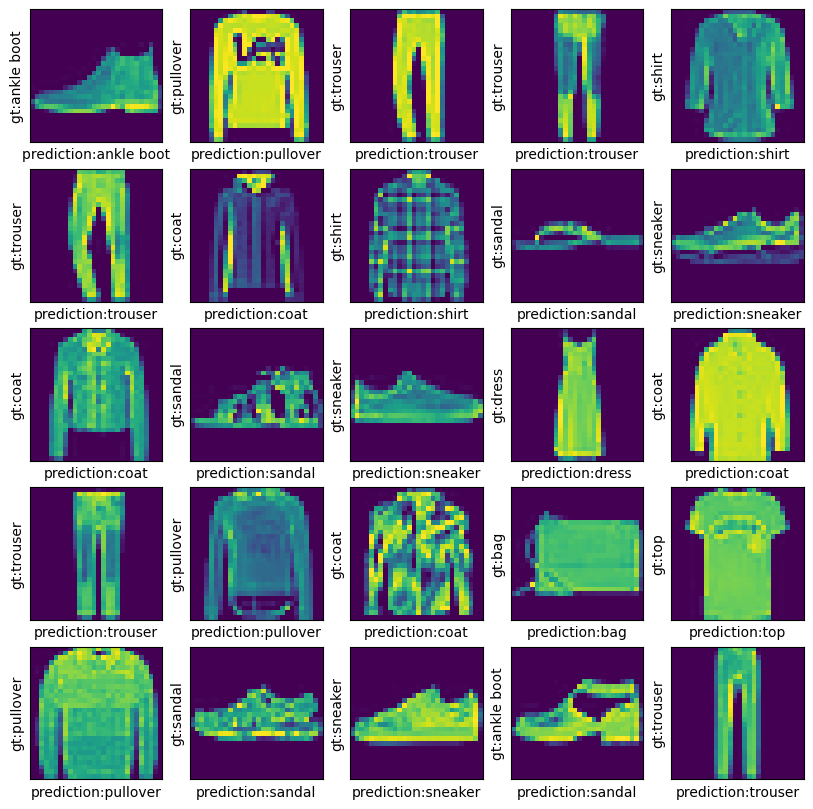

In [46]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_test[i])
    plt.xlabel(f'prediction:{class_names[np.argmax(y_pred[i])]}')
    plt.ylabel(f'gt:{class_names[y_test.flatten()[i]]}')
plt.show()